# Capitolo 3: Il Divario Strutturale. Italia vs Europa
Questo notebook analizza i dataset ufficiali Eurostat per mappare lo stato del capitale umano e delle strategie di sicurezza aziendale. L'elaborazione evidenzia il divario strutturale dell'Italia rispetto alla media UE e ai Best Performers, focalizzandosi sulla carenza di specialisti ICT, la mancanza di formazione interna e l'elevata dipendenza dall'outsourcing informatico.

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'

def get_latest_eurostat_data(filepath, target_countries):
    df = pl.read_csv(filepath, null_values=[":", " : "], ignore_errors=True)

    df_filtered = df.filter(pl.col("Geopolitical entity (reporting)").is_in(target_countries))

    df_filtered = df_filtered.with_columns(pl.col("OBS_VALUE").cast(pl.Float64, strict=False))

    df_latest = df_filtered.sort("TIME_PERIOD", descending=True).unique(
        subset=["Geopolitical entity (reporting)"], keep="first"
    )

    return df_latest

## 3.1 Divario di capitale umano: specialisti ICT in Europa

Questo grafico mostra la percentuale di specialisti ICT rispetto al totale dei lavoratori. Confrontando l'Italia con la media dell'Unione Europea (UE-27) e con i due Best Performers (Svezia e Finlandia).


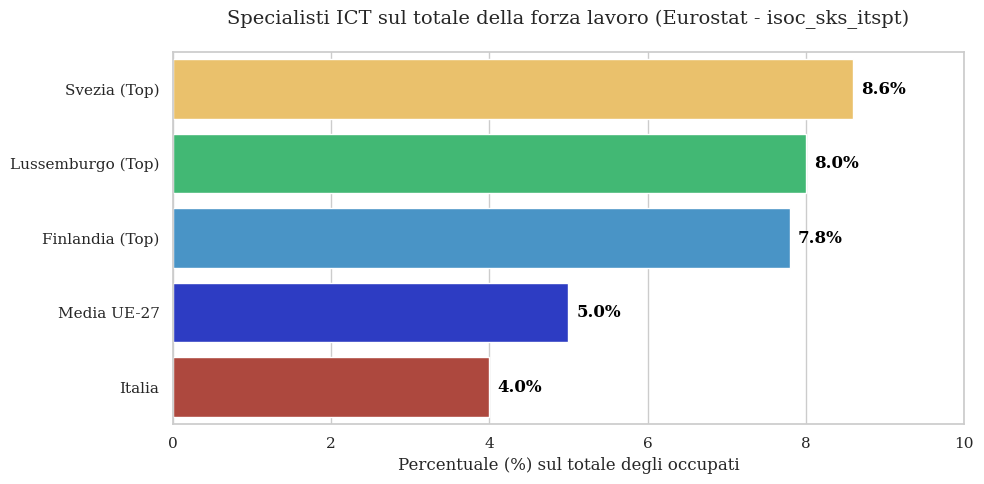

In [2]:
countries_spec = ["Sweden", "Finland", "Luxembourg", "European Union - 27 countries (from 2020)", "Italy"]
df_spec = get_latest_eurostat_data("../data/raw/isoc_sks_itspt_ict_employed.csv", countries_spec)

mapping_spec = {
    "Sweden": "Svezia (Top)",
    "Finland": "Finlandia (Top)",
    "Luxembourg": "Lussemburgo (Top)",
    "European Union - 27 countries (from 2020)": "Media UE-27",
    "Italy": "Italia"
}
df_spec = df_spec.with_columns(
    pl.col("Geopolitical entity (reporting)").replace(mapping_spec).alias("Nazione/Area")
).sort("OBS_VALUE", descending=True)

plt.figure(figsize=(10, 5), facecolor='white')
palette_spec = ['#FFC857', '#2ecc71', '#3498db', '#1428dc', '#c0392b']

ax1 = sns.barplot(
    data=df_spec.to_pandas(),
    x="OBS_VALUE",
    y="Nazione/Area",
    hue="Nazione/Area",
    palette=palette_spec,
    legend=False
)

for i, v in enumerate(df_spec["OBS_VALUE"].to_list()):
    ax1.text(v + 0.1, i, f"{v}%", va='center', fontweight='bold', color='black')

plt.title("Specialisti ICT sul totale della forza lavoro (Eurostat - isoc_sks_itspt)", fontsize=14, pad=20)
plt.xlabel("Percentuale (%) sul totale degli occupati")
plt.ylabel("")
plt.xlim(0, 10)
plt.tight_layout()
plt.savefig("figura_3_1_specialisti_ict.png", facecolor='white', transparent=False)
plt.show()

## 3.2 Il problema aziendale: assunzioni e formazione a confronto
Questa visualizzazione a barre mette in luce l'assenza di una reale cultura informatica nelle imprese italiane. Il grafico confronta l'Italia con la media UE su due metriche speculari: da un lato, la percentuale di aziende che cerca attivamente di reclutare personale con competenze ICT; dall'altro, la quota di imprese che investe nella formazione informatica dei dipendenti già in organico.


In [ ]:
countries_strat = ["European Union - 27 countries (from 2020)", "Italy"]

df_recruiting = get_latest_eurostat_data("../data/raw/isoc_ske_itrcrn2_recruited_or_tried.csv", countries_strat)
df_recruiting = df_recruiting.with_columns(pl.lit("Ricerca Personale ICT").alias("Metrica"))

df_training = get_latest_eurostat_data("../data/raw/isoc_ske_ittn2_training_to_personnel.csv", countries_strat)
df_training = df_training.with_columns(pl.lit("Formazione Dipendenti").alias("Metrica"))

df_strat = pl.concat([df_recruiting, df_training])

df_strat = df_strat.with_columns(
    pl.col("Geopolitical entity (reporting)")
    .replace({"European Union - 27 countries (from 2020)": "Media UE-27", "Italy": "Italia"})
    .alias("Area")
)

plt.figure(figsize=(9, 6), facecolor='white')
palette_strat = {'Media UE-27': '#34495e', 'Italia': '#c0392b'}

ax2 = sns.barplot(
    data=df_strat.to_pandas(),
    x="Metrica",
    y="OBS_VALUE",
    hue="Area",
    palette=palette_strat
)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold', fontsize=11)

plt.title("Il problema aziendale: assunzioni e formazione (Eurostat - isoc_ske_itrcrn2)", fontsize=14, pad=20)
plt.xlabel("")
plt.ylabel("Percentuale di imprese (%)")
plt.ylim(0, 35)
plt.legend(title="")
plt.tight_layout()
plt.savefig("figura_3_2_strategia_aziendale.png", facecolor='white', transparent=False)
plt.show()

## 3.3 Esternalizzazione della sicurezza e rischio supply chain
In quest'ultima sezione analizziamo l'approccio delle aziende alla gestione delle proprie infrastrutture informatiche. Il grafico illustra la netta polarizzazione del mercato italiano verso l'outsourcing totale, confrontando le imprese che delegano le funzioni ICT "esclusivamente a fornitori esterni" (MSP) con quelle che si affidano "esclusivamente a personale interno".

In [ ]:
df_ext = get_latest_eurostat_data("../data/raw/isoc_ske_fctn2_ict_functions_only_by_external.csv", countries_strat)
df_ext = df_ext.with_columns(pl.lit("Solo Fornitori Esterni)").alias("Modello di Gestione"))

df_own = get_latest_eurostat_data("../data/raw/isoc_ske_fctn2_only_by_own_emp.csv", countries_strat)
df_own = df_own.with_columns(pl.lit("Solo Personale Interno").alias("Modello di Gestione"))

df_outsource = pl.concat([df_ext, df_own])

df_outsource = df_outsource.with_columns(
    pl.col("Geopolitical entity (reporting)")
    .replace({"European Union - 27 countries (from 2020)": "Media UE-27", "Italy": "Italia"})
    .alias("Area")
)

plt.figure(figsize=(9, 6), facecolor='white')

ax3 = sns.barplot(
    data=df_outsource.to_pandas(),
    x="Modello di Gestione",
    y="OBS_VALUE",
    hue="Area",
    palette=palette_strat
)

for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold', fontsize=11)

plt.title("Esternalizzazione della sicurezza: outsourcing vs In-House (Eurostat - isoc_ske_fctn2)", fontsize=14, pad=20)
plt.xlabel("")
plt.ylabel("Percentuale di Imprese (%)")
plt.ylim(0, 70)
plt.legend(title="")
plt.tight_layout()
plt.savefig("figura_3_3_outsourcing_risk.png", facecolor='white', transparent=False)
plt.show()